###  GENERAL LIBRARIES IMPORTS 

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### FETCH STANDARD CHARTERED STOCKS

In [83]:
df_orig = pd.read_csv('total_kenya_stocks.csv')
df_orig.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust,Date,Adjusted
0,1/4/2010,TOTL,Total Kenya,12.65,18,28.5,30.0,29.25,29.75,-0.5,1.71%,"8,200",-,NaN,NaN
1,1/5/2010,TOTL,Total Kenya,12.65,18,28.5,30.0,28.50,29.25,-0.75,2.63%,"1,100",-,NaN,NaN
2,1/6/2010,TOTL,Total Kenya,12.65,18,29.0,30.0,29.00,28.50,0.5,1.72%,"25,900",-,NaN,NaN
3,1/7/2010,TOTL,Total Kenya,12.65,18,30.0,30.0,30.00,29.00,1,3.33%,500,-,NaN,NaN
4,1/8/2010,TOTL,Total Kenya,12.65,18,30.0,30.0,30.00,30.00,-,-,"2,600",-,NaN,NaN


### HANDLING MISSING VALUES IN THE STOCK DATASET

- remove the adjust, date, adjusted data, stock name, change percentage, change columns
- simply omitting columns that are needless to the end goal
- drop the rows that have missing values

In [84]:
# a duplicate of the original dataset without the unnecessary columns
df = df_orig.copy()
df.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust,Date,Adjusted
0,1/4/2010,TOTL,Total Kenya,12.65,18,28.5,30.0,29.25,29.75,-0.5,1.71%,"8,200",-,NaN,NaN
1,1/5/2010,TOTL,Total Kenya,12.65,18,28.5,30.0,28.50,29.25,-0.75,2.63%,"1,100",-,NaN,NaN
2,1/6/2010,TOTL,Total Kenya,12.65,18,29.0,30.0,29.00,28.50,0.5,1.72%,"25,900",-,NaN,NaN
3,1/7/2010,TOTL,Total Kenya,12.65,18,30.0,30.0,30.00,29.00,1,3.33%,500,-,NaN,NaN
4,1/8/2010,TOTL,Total Kenya,12.65,18,30.0,30.0,30.00,30.00,-,-,"2,600",-,NaN,NaN


In [85]:
df.isna().sum()

DATE          246
CODE            0
NAME            0
12m Low         0
12m High        0
Day Low         0
Day High        0
Day Price       0
Previous        0
Change          0
Change%         0
Volume          0
Adjust        246
Date         1251
Adjusted     1251
dtype: int64

In [86]:
columns = ['Adjust', 'Date', 'Adjusted', 'NAME', 'Change%', 'Change']
df = df.drop(columns, axis=1)
df.head()

,DATE,CODE,12m Low,12m High,Day Low,Day High,Day Price,Previous,Volume
0,1/4/2010,TOTL,12.65,18,28.5,30.0,29.25,29.75,"8,200"
1,1/5/2010,TOTL,12.65,18,28.5,30.0,28.50,29.25,"1,100"
2,1/6/2010,TOTL,12.65,18,29.0,30.0,29.00,28.50,"25,900"
3,1/7/2010,TOTL,12.65,18,30.0,30.0,30.00,29.00,500
4,1/8/2010,TOTL,12.65,18,30.0,30.0,30.00,30.00,"2,600"


In [87]:
df = df.dropna(subset=['DATE'])
df.isna().sum()

DATE         0
CODE         0
12m Low      0
12m High     0
Day Low      0
Day High     0
Day Price    0
Previous     0
Volume       0
dtype: int64

### DROP THE DATES COLUMN
- converted the dates yyyy/mm/dd into separate three-way values to ease removal of the column
- extract the year, month and date
- omit the commas on the numbers and converted them to numeric form

In [88]:
# Convert date column to datetime type
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%Y', errors='coerce')

# Extract Date Data to Different Columns
df['day'] = df['DATE'].dt.day
df['month'] = df['DATE'].dt.month
df['year'] = df['DATE'].dt.year

# Drop the date column
df = df.drop("DATE", axis=1)

df.head()

,CODE,12m Low,12m High,Day Low,Day High,Day Price,Previous,Volume,day,month,year
0,TOTL,12.65,18,28.5,30.0,29.25,29.75,"8,200",1.0,4.0,2010.0
1,TOTL,12.65,18,28.5,30.0,28.50,29.25,"1,100",1.0,5.0,2010.0
2,TOTL,12.65,18,29.0,30.0,29.00,28.50,"25,900",1.0,6.0,2010.0
3,TOTL,12.65,18,30.0,30.0,30.00,29.00,500,1.0,7.0,2010.0
4,TOTL,12.65,18,30.0,30.0,30.00,30.00,"2,600",1.0,8.0,2010.0


In [89]:
columns = ['day', 'month', 'year', 'CODE']
df = df.drop(columns, axis=1)
df.head()

,12m Low,12m High,Day Low,Day High,Day Price,Previous,Volume
0,12.65,18,28.5,30.0,29.25,29.75,"8,200"
1,12.65,18,28.5,30.0,28.50,29.25,"1,100"
2,12.65,18,29.0,30.0,29.00,28.50,"25,900"
3,12.65,18,30.0,30.0,30.00,29.00,500
4,12.65,18,30.0,30.0,30.00,30.00,"2,600"


In [90]:
df = df.replace('-', np.nan)
df.isna().sum()

12m Low      0
12m High     0
Day Low      0
Day High     0
Day Price    0
Previous     0
Volume       0
dtype: int64

In [91]:
df['Volume'] = df['Volume'].str.replace(',', '').astype(float)
df.isna().sum()

12m Low      0
12m High     0
Day Low      0
Day High     0
Day Price    0
Previous     0
Volume       0
dtype: int64

## STOCK PREDICTION

1. k-NN
2. Linear Regression
3. Random Forest Regressor



In [92]:
from sklearn.model_selection import train_test_split
np.random.seed(42)

# Create the data
X = df.drop('Day Price', axis=1)
y = df['Day Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

X_train.head()

,12m Low,12m High,Day Low,Day High,Previous,Volume
66,12.65,18,29.50,30.00,29.50,5700.0
67,12.65,18,30.00,30.25,29.75,14000.0
628,12.65,18,23.00,24.00,23.75,65100.0
211,12.65,18,29.00,30.50,30.50,123400.0
12,12.65,18,30.25,32.00,30.75,6100.0


In [93]:
from sklearn.neighbors import KNeighborsRegressor as KNN

np.random.seed(40)

# Initiate the model
knn = KNN(n_neighbors=4)

# Fit the model
knn.fit(X_train, y_train)

# Check score
knn.score(X_test, y_test)

0.256002196107742

In [94]:
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# Initiate the model
lr = LinearRegression()

# Fit the model
lr.fit(X_train, y_train)

# Check score
lr.score(X_test, y_test)

0.9982349413676745

In [95]:
from sklearn.ensemble import RandomForestRegressor as RFR

np.random.seed(42)

# Initiate the model
rf = RFR()

# Fit the model
rf.fit(X_train, y_train)

# Check score
rf.score(X_test, y_test)

0.9975961617403903

###  EVALUATION OF THE MODELS USED

better analysis of the regression models

- using the mean squared error, root mean squared error, r2-square
- using the residual plot (residual = observed - predicted); residuals centered around zero indicate overall unbiasness of the models, suggest not too much overestimating nor too much underestimating
- using the error plot, which visually represents the residuals uniformly scattered around the horizontal line at zero

In [96]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

models = {
    "KNeighbors Regressor": knn,
    "Linear Regressor": lr,
    "Random Forest Regressor": rf
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    results[name] = {
        "Mean Squared Error": mse,
        "Root Mean Squared Error": rmse,
        "R-square (R2)": r2
    }

# Convert the dictionary to a DataFrame
table = pd.DataFrame(results).T
table

,Mean Squared Error,Root Mean Squared Error,R-square (R2)
KNeighbors Regressor,28.948386,5.380370,0.256002
Linear Regressor,0.068677,0.262063,0.998235
Random Forest Regressor,0.093532,0.305829,0.997596


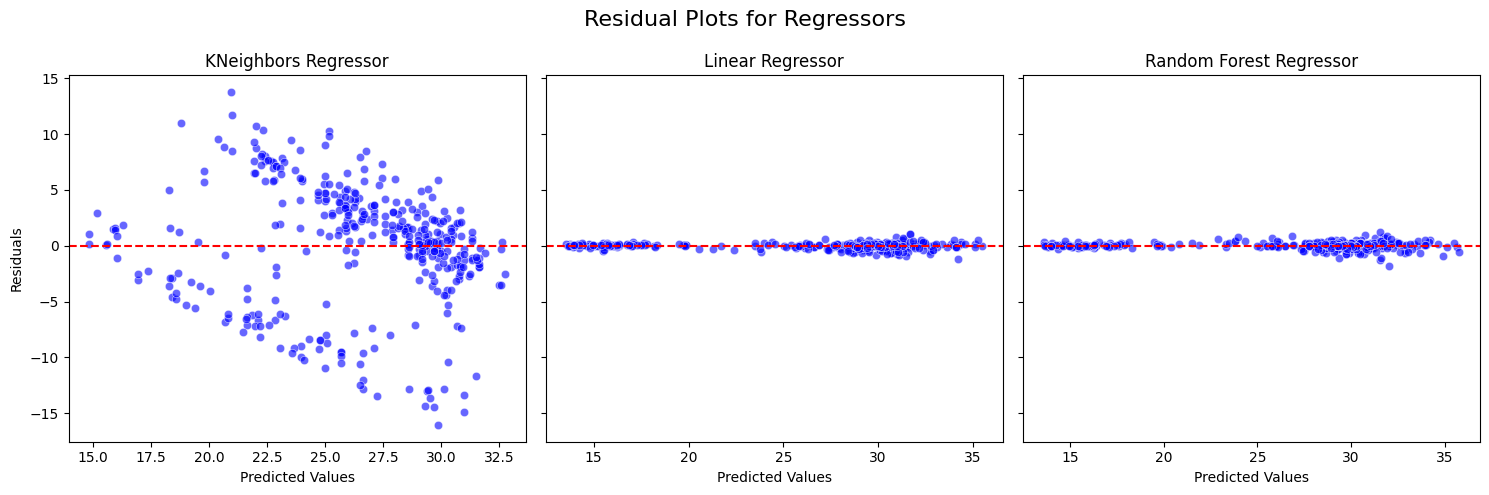

In [97]:
# Initialize a plot grid
fig, axes = plt.subplots(nrows=1, ncols=len(
    models), figsize=(15, 5), sharey=True)
fig.suptitle("Residual Plots for Regressors", fontsize=16)

# Loop through models to create residual plots
for i, (name, model) in enumerate(models.items()):
    # Train the model
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate residuals
    residuals = y_test - y_pred

    # Plot residuals
    ax = axes[i]
    sns.scatterplot(x=y_pred, y=residuals, ax=ax, color='blue', alpha=0.6)
    # Horizontal line at residual = 0
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(name)
    ax.set_xlabel("Predicted Values")
    # Only label y-axis for first plot
    ax.set_ylabel("Residuals" if i == 0 else "")

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust title position
plt.show()

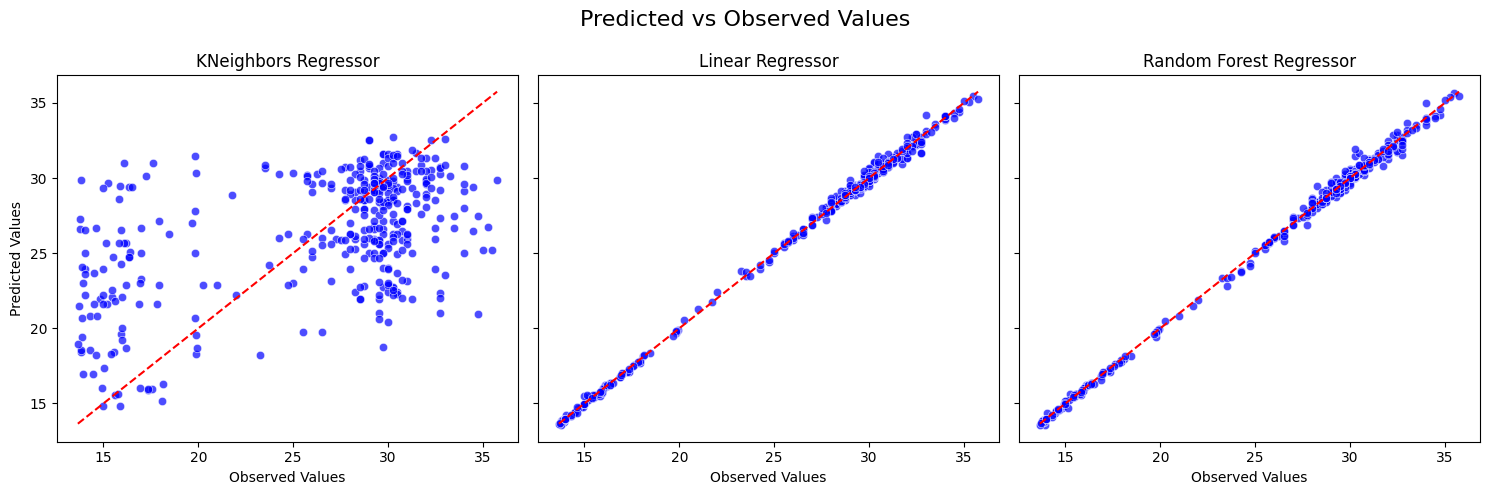

In [98]:
# Initialize a plot grid
fig, axes = plt.subplots(nrows=1, ncols=len(
    models), figsize=(15, 5), sharey=True)
fig.suptitle("Predicted vs Observed Values", fontsize=16)

# Loop through models to create the predicted vs actual plots
for i, (name, model) in enumerate(models.items()):
    # Train the model
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Plot actual vs predicted
    ax = axes[i]
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, color='blue', alpha=0.7)

    # Add a reference line (y = x) for perfect predictions
    ax.plot([min(y_test), max(y_test)], [min(y_test),
            max(y_test)], color='red', linestyle='--')

    # Titles and labels
    ax.set_title(name)
    ax.set_xlabel("Observed Values")
    # Label y-axis only for the first plot
    ax.set_ylabel("Predicted Values" if i == 0 else "")

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust title position
plt.show()